# CausalPype: Output Types Demo

Every output type the library produces — organized by format, not by domain.

| Section | Task | Output type |
|---------|------|-------------|
| 1 | ATE | Scalar `estimate` |
| 2 | ArrowStrength | Dict `estimate` |
| 3 | CausalEffectCurve | DataFrame `estimate` |
| 4 | Validate | String `estimate` |
| 5 | — | `plot_graph` |
| 6 | — | `plot_effects` (multiple tasks) |
| 7 | — | `model.report()` text & dict |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from causalpype import CausalModel
from causalpype import plotting

## Data & Model

A simple 3-node linear SCM — no downloads required.

```
Z → X → Y
Z --------→ Y
```

True ATE(X→Y) ≈ 1.5 (direct effect only, since Z is a confounder).

In [2]:
np.random.seed(42)
n = 1_000

Z = np.random.normal(0, 1, n)
X = 0.8 * Z + np.random.normal(0, 0.5, n)
Y = 1.5 * X + 0.5 * Z + np.random.normal(0, 0.5, n)

df = pd.DataFrame({'Z': Z, 'X': X, 'Y': Y})

G = nx.DiGraph([('Z', 'X'), ('Z', 'Y'), ('X', 'Y')])

model = CausalModel(G, auto_assign=True, assignment_quality='good')
model.fit(df)

print(model)

Fitting causal mechanism of node Y: 100%|██████████| 3/3 [00:00<00:00, 894.69it/s]

CausalModel(fitted, nodes=['Z', 'X', 'Y'], edges=[('Z', 'X'), ('Z', 'Y'), ('X', 'Y')])


---
## 1. Scalar estimate — `ATE`

`estimate` is a single float. Three ways to access it:

In [3]:
from causalpype import ATE

r_ate = model.run(ATE('X', 'Y'))

# 1a. Pretty-printed summary
r_ate.summary()

                       ATE Results                        
 Treatment                                               X
 Outcome                                                 Y
 Treatment Value                                         1
 Control Value                                           0
----------------------------------------------------------
 Estimate                                           1.5017
 Num Samples                                         2,000


In [4]:
# 1b. Raw fields
print('estimate :', r_ate.estimate)
print('details  :', r_ate.details)

estimate : 1.5017034171388626
details  : {'treatment': 'X', 'outcome': 'Y', 'treatment_value': 1, 'control_value': 0, 'num_samples': 2000}


In [5]:
# 1c. JSON-safe dict (for logging / experiment trackers)
r_ate.to_dict()

{'task_name': 'ATE',
 'estimate': 1.5017034171388626,
 'details': {'treatment': 'X',
  'outcome': 'Y',
  'treatment_value': 1,
  'control_value': 0,
  'num_samples': 2000}}

---
## 2. Dict estimate — `ArrowStrength`

`estimate` is a `{"parent -> target": float}` dict. Comes with a dedicated bar-chart plot.

In [6]:
from causalpype import ArrowStrength

r_arrow = model.run(ArrowStrength('Y'))
r_arrow.summary()

                  Arrow Strength Results                  
 Target                                                  Y
----------------------------------------------------------
  X -> Y                                            1.8123
  Z -> Y                                            0.2692


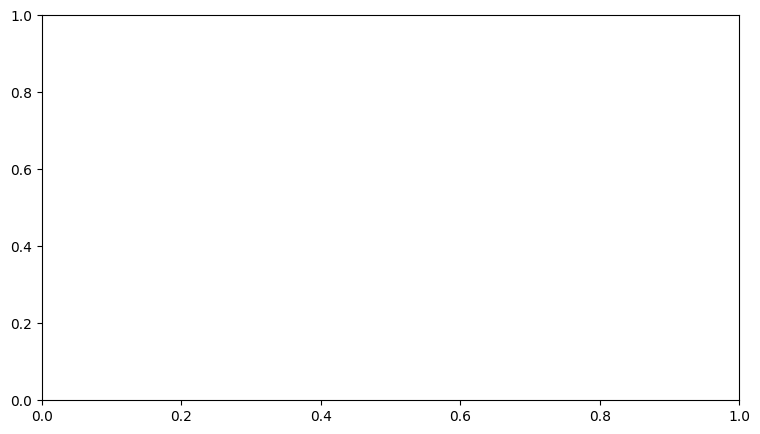

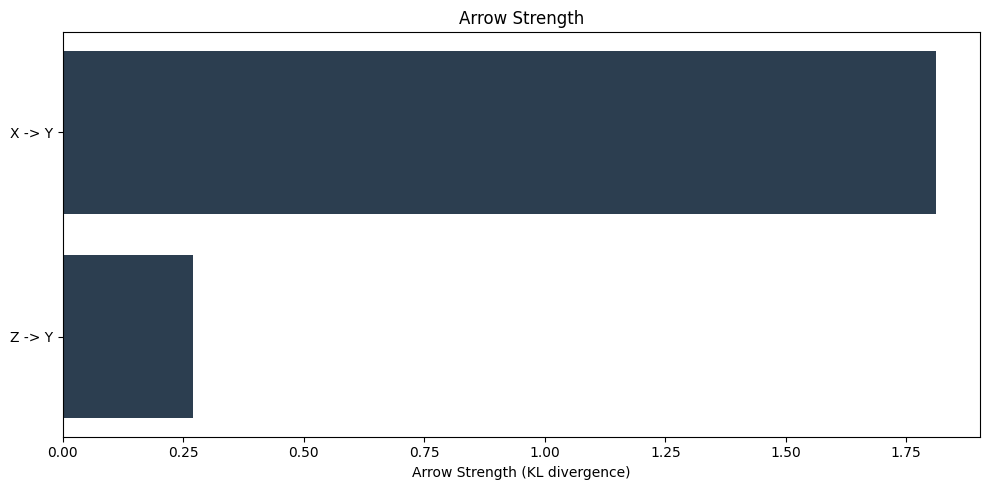

In [7]:
plotting.plot_arrow_strength(r_arrow)
plt.show()

---
## 3. Dose-response curve — `CausalEffectCurve`

`estimate` is a DataFrame of `(treatment_value, expected_outcome, std)` rows.

In [8]:
from causalpype import CausalEffectCurve

r_curve = model.run(CausalEffectCurve('X', 'Y', n_points=15, num_samples=500))
r_curve.summary()

               Causal Effect Curve Results                
 Treatment                                               X
 Outcome                                                 Y
----------------------------------------------------------
 do(X)                   E[Y]        Std
----------------------------------------------------------
 -2.4354              -3.6262     0.6863
 -1.9788              -2.9012     0.6564
 -1.5222              -2.2605     0.6536
 -1.0656              -1.5804     0.6798
 -0.6090              -0.8499     0.6910
                  ...                 
 2.1306                3.2144     0.7115
 2.5872                3.9250     0.7129
 3.0438                4.5176     0.7155
 3.5004                5.1684     0.7399
 3.9570                5.9535     0.7144


In [9]:
# The underlying DataFrame is in details
r_curve.details['response_df'].head()

,treatment_value,expected_outcome,std
0,-2.435428,-3.626208,0.686279
1,-1.978828,-2.901174,0.656416
2,-1.522228,-2.260497,0.653577
3,-1.065628,-1.580374,0.679846
4,-0.609028,-0.849876,0.690991


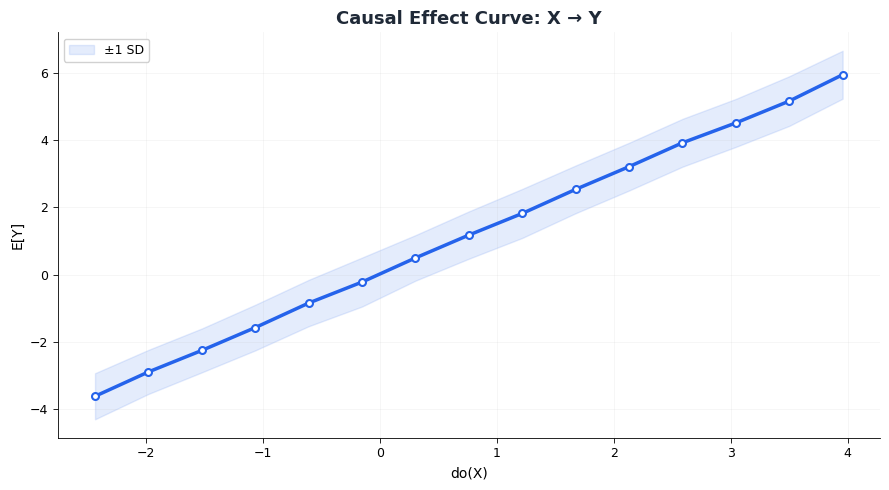

In [10]:
plotting.plot_causal_effect_curve(r_curve)
plt.show()

---
## 4. String estimate — `Validate`

`estimate` is `"passed"` or `"issues_found"`. Details contain per-test breakdowns.

In [11]:
from causalpype import Validate

r_val = model.run(Validate())
r_val.summary()

                    Validation Results                    
 Result                                             PASSED
----------------------------------------------------------
 Structure Validation
    Passed                                             Yes
    N Tests                                              3
    Bonferroni Level                                0.0167
----------------------------------------------------------
 Model Validation
    Passed                                             Yes
    Result                                    NOT_REJECTED


In [12]:
print('estimate :', r_val.estimate)   # the verdict string
print('details  :', r_val.details)

estimate : passed
details  : {'structure': {'passed': True, 'edge_tests': {'Z -> X': {'p_value': np.float64(0.0), 'success': np.True_}, 'X -> Y': {'p_value': np.float64(0.0), 'success': np.True_}, 'Z -> Y': {'p_value': np.float64(0.0), 'success': np.True_}}, 'node_details': {'X': {'Z -> X': {'p_value': np.float64(0.0), 'success': np.True_}}, 'Y': {'X -> Y': {'p_value': np.float64(0.0), 'success': np.True_}, 'Z -> Y': {'p_value': np.float64(0.0), 'success': np.True_}}}, 'n_tests': 3, 'bonferroni_level': 0.016666666666666666}, 'model': {'passed': True, 'result': 'NOT_REJECTED'}}


---
## 5. Graph plot — `plot_graph`

Renders the causal DAG. Pass an `ArrowStrength` result to colour edges by strength.

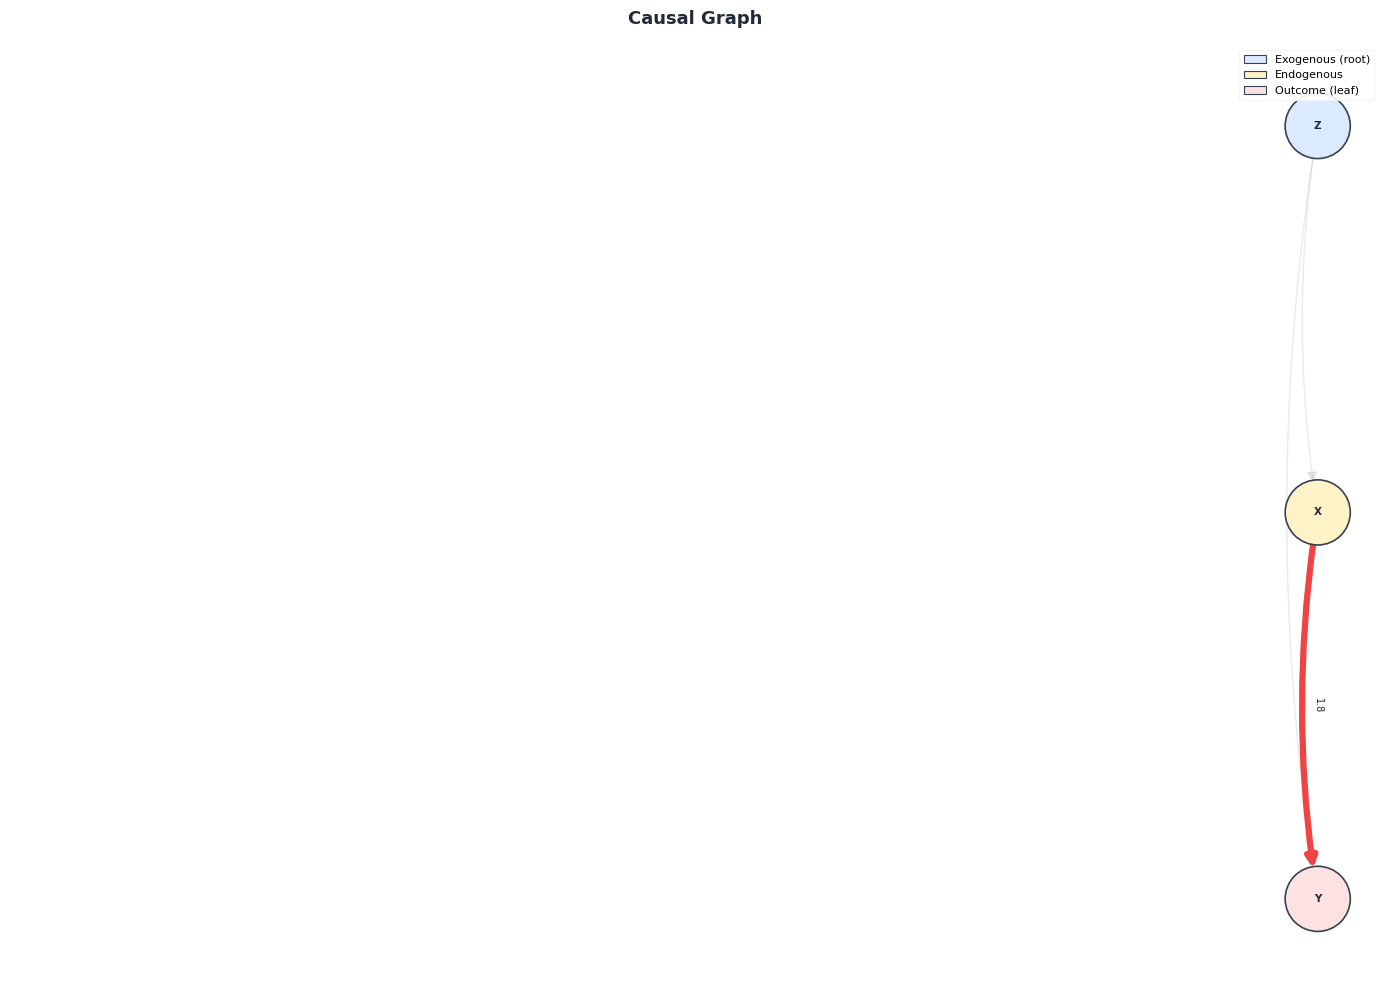

In [13]:
plotting.plot_graph(model, strengths=r_arrow)
plt.show()

---
## 6. Effects plot — `plot_effects`

Accepts a single `TaskResult` or a list — useful for comparing multiple treatment effects side by side.

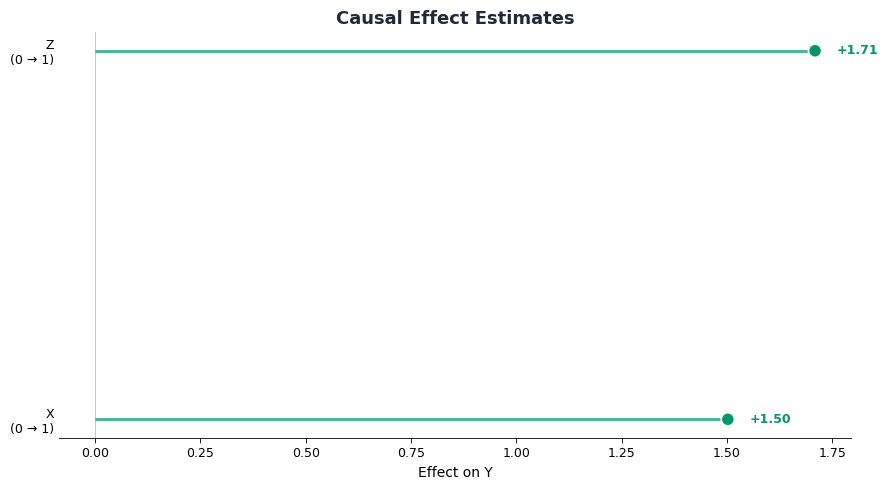

In [14]:
r_ate_z = model.run(ATE('Z', 'Y'))

plotting.plot_effects([r_ate, r_ate_z])
plt.show()

---
## 7. Full report — `model.report()`

Runs after a pipeline to produce either a formatted text summary or a structured dict.

In [15]:
# Run a batch pipeline so the report has multiple results
model.run([
    ATE('X', 'Y'),
    ATE('Z', 'Y'),
    ArrowStrength('Y'),
    CausalEffectCurve('X', 'Y', n_points=10, num_samples=500),
    Validate(),
])

[                       ATE Results                        
  Treatment                                               X
  Outcome                                                 Y
  Treatment Value                                         1
  Control Value                                           0
 ----------------------------------------------------------
  Estimate                                           1.4744
  Num Samples                                         2,000
 ==========================================================,
                        ATE Results                        
  Treatment                                               Z
  Outcome                                                 Y
  Treatment Value                                         1
  Control Value                                           0
 ----------------------------------------------------------
  Estimate                                           1.6331
  Num Samples                          

In [16]:
# format="text" → human-readable terminal output
print(model.report(format='text'))

CausalPype Analysis Report

--- Causal Graph ---
  Nodes (3): ['Z', 'X', 'Y']
  Edges (3): [('Z', 'X'), ('Z', 'Y'), ('X', 'Y')]
  Root nodes: ['Z']
  Leaf nodes: ['Y']

--- Data ---
  Rows: 1000
  Columns: 3

                       ATE Results                        
 Treatment                                               X
 Outcome                                                 Y
 Treatment Value                                         1
 Control Value                                           0
----------------------------------------------------------
 Estimate                                           1.4744
 Num Samples                                         2,000

                       ATE Results                        
 Treatment                                               Z
 Outcome                                                 Y
 Treatment Value                                         1
 Control Value                                           0
-----------------------

In [17]:
# format="dict" → JSON-serializable nested dict
report = model.report(format='dict')
print('Top-level keys:', list(report.keys()))
print('Graph summary :', report['graph'])
print('\nNumber of task results:', len(report['results']))
print('First result keys:', list(report['results'][0].keys()))

Top-level keys: ['graph', 'data', 'results']
Graph summary : {'nodes': ['Z', 'X', 'Y'], 'edges': [('Z', 'X'), ('Z', 'Y'), ('X', 'Y')], 'n_nodes': 3, 'n_edges': 3}

Number of task results: 5
First result keys: ['task_name', 'estimate', 'details']


In [18]:
report

{'graph': {'nodes': ['Z', 'X', 'Y'],
  'edges': [('Z', 'X'), ('Z', 'Y'), ('X', 'Y')],
  'n_nodes': 3,
  'n_edges': 3},
 'data': {'n_rows': 1000, 'columns': ['Z', 'X', 'Y']},
 'results': [{'task_name': 'ATE',
   'estimate': 1.4744290747198043,
   'details': {'treatment': 'X',
    'outcome': 'Y',
    'treatment_value': 1,
    'control_value': 0,
    'num_samples': 2000}},
  {'task_name': 'ATE',
   'estimate': 1.6331465012730177,
   'details': {'treatment': 'Z',
    'outcome': 'Y',
    'treatment_value': 1,
    'control_value': 0,
    'num_samples': 2000}},
  {'task_name': 'Arrow Strength',
   'estimate': {'X -> Y': 1.8802604153985265, 'Z -> Y': 0.2615620711884192},
   'details': {'target': 'Y',
    'strengths': {'X -> Y': 1.8802604153985265, 'Z -> Y': 0.2615620711884192},
    'raw_strengths': {"('X', 'Y')": 1.8802604153985265,
     "('Z', 'Y')": 0.2615620711884192}}},
  {'task_name': 'Causal Effect Curve',
   'estimate': [{'treatment_value': -2.4354280406488367,
     'expected_outcome': 